
# Convección natural: enfriamiento de botellas de vino en orientación horizontal y vertical

## Objetivo

Comparar cuál se enfría más rápido por **convección natural en aire**:

- una botella de vino en **posición horizontal**,
- o una botella de vino en **posición vertical**.

Además, comparar distintas dimensiones de botella.

Se supondrá que:

- la botella está inicialmente a temperatura uniforme,
- el aire ambiente está a temperatura uniforme y en reposo,
- la resistencia dominante es la convección natural exterior,
- el vidrio es delgado y el contenido interno del vino se mezcla suficientemente rápido como para poder aplicar un **modelo de capacidad concentrada**.

![Vino](wine_bottles.png)

---

## Modelo físico

El enfriamiento del vino se modela con:

$
m c_p \frac{dT}{dt} = - h A_s (T - T_\infty)
$

donde:

- \(m\) = masa del vino,
- \(c_p\) = calor específico del vino,
- \(h\) = coeficiente convectivo por convección natural,
- \(A_s\) = área superficial externa de la botella,
- \(T\) = temperatura del vino,
- \(T_\infty\) = temperatura del aire ambiente.

La solución de esta ecuación es:

$
T(t) = T_\infty + (T_i - T_\infty)\exp\left(-\frac{h A_s}{m c_p}t\right)
$

Por tanto, el enfriamiento será más rápido cuando el parámetro

$
\frac{hA_s}{m c_p}
$

sea mayor.

---

## Geometría idealizada

Aproximaremos la botella como un cilindro de diámetro \(D\) y longitud \(L\), despreciando el cuello para mantener el ejemplo claro y didáctico.

Entonces:

$
A_s = \pi D L + 2\left(\frac{\pi D^2}{4}\right)
$

$
V = \frac{\pi D^2}{4}L
$

$
m = \rho_{vino} V
$

---

## Temperatura de película

Las propiedades del aire se evalúan a la temperatura de película:

$
T_f = \frac{T_s + T_\infty}{2}
$

En este ejemplo, para simplificar el uso de correlaciones, se aproxima \(T_s \approx T\), es decir, la temperatura superficial de la botella se toma cercana a la temperatura media del vino.

Las propiedades del aire se obtendrán con **CoolProp**:

- densidad $\(\rho\)$,
- viscosidad dinámica $\(\mu\)$,
- conductividad térmica $\(k\)$,
- calor específico $\(c_p\)$,

y se calculan:

$
\nu = \frac{\mu}{\rho}
$

$
\alpha = \frac{k}{\rho c_p}
$

$
Pr = \frac{\nu}{\alpha}
$

$
\beta \approx \frac{1}{T_f}
$

---

## Número de Rayleigh

$
Ra_L = \frac{g \beta (T_s - T_\infty)L_c^3}{\nu \alpha} = Gr_L Pr
$

donde \(L_c\) es la longitud característica.

---

## Correlaciones usadas

### 1. Botella horizontal

La botella horizontal se aproxima como un **cilindro horizontal** en convección natural.

Se usa la correlación:

$
\overline{Nu}_D =
\left[
0.60 +
\frac{0.387\,Ra_D^{1/6}}
{\left(1 + (0.559/Pr)^{9/16}\right)^{8/27}}
\right]^2
$

válida ampliamente para cilindros horizontales en aire.

Luego:

$
h_h = \frac{\overline{Nu}_D\,k}{D}
$

---

### 2. Botella vertical

La botella vertical se aproxima como un **cilindro vertical alto**, y para fines docentes se modela con la correlación de **placa vertical isoterma** usando como longitud característica la altura \(L\):

$
\overline{Nu}_L =
\left[
0.825 +
\frac{0.387\,Ra_L^{1/6}}
{\left(1 + (0.492/Pr)^{9/16}\right)^{8/27}}
\right]^2
$

Luego:

$
h_v = \frac{\overline{Nu}_L\,k}{L}
$

Esta comparación es físicamente razonable para mostrar el efecto de la orientación sobre la convección natural.

---

## Criterio de comparación

Para cada botella y orientación se calcularán:

1. \(h\),
2. la constante de enfriamiento
   $
   b=\frac{hA_s}{mc_p}
   $
3. el tiempo necesario para alcanzar una temperatura objetivo \(T_{obj}\), obtenido de:

$
t = \frac{1}{b}\ln\left(\frac{T_i-T_\infty}{T_{obj}-T_\infty}\right)
$

---

## Qué se espera físicamente

- En la **posición vertical**, la flotación favorece el desarrollo de una capa límite natural a lo largo de una longitud mayor.
- En la **posición horizontal**, la longitud característica suele ser el diámetro, y la distribución de la capa límite es distinta.
- Dependiendo de la geometría, una orientación puede producir un \(h\) mayor que la otra.
- También influye el área superficial por unidad de volumen.

El siguiente código realiza toda la comparación en **una sola celda**.


RESUMEN DE RESULTADOS


,Botella,D [m],L [m],Volumen [L],Area [m²],Masa vino [kg],h horizontal [W/m²K],Nu horizontal,Ra_D,b horizontal [1/s],t_obj horizontal [min],h vertical [W/m²K],Nu vertical,Ra_L,b vertical [1/s],t_obj vertical [min],Más rápido
0,Botella esbelta 375 mL,0.060,0.22,0.6220,0.0471,0.6158,3.8909,8.9199,168329.3676,7.6345e-05,151.3189,3.5204,29.5914,8.2980e+06,6.9074e-05,167.2480,Horizontal
1,Botella estándar 750 mL,0.076,0.30,1.3609,0.0807,1.3473,3.7186,10.7982,342095.1503,5.7111e-05,202.2790,3.3686,38.6128,2.1041e+07,5.1736e-05,223.2942,Horizontal
2,Botella ancha 1.0 L,0.090,0.30,1.9085,0.0975,1.8894,3.6094,12.4116,568111.6156,4.7780e-05,241.7851,3.3686,38.6128,2.1041e+07,4.4593e-05,259.0622,Horizontal
3,Magnum 1.5 L,0.105,0.35,3.0307,0.1328,3.0003,3.5187,14.1166,902140.2044,3.9926e-05,289.3474,3.3026,44.1653,3.3413e+07,3.7474e-05,308.2816,Horizontal



CONCLUSIÓN AUTOMÁTICA:
- Botella esbelta 375 mL: se enfría más rápido en orientación Horizontal.
- Botella estándar 750 mL: se enfría más rápido en orientación Horizontal.
- Botella ancha 1.0 L: se enfría más rápido en orientación Horizontal.
- Magnum 1.5 L: se enfría más rápido en orientación Horizontal.


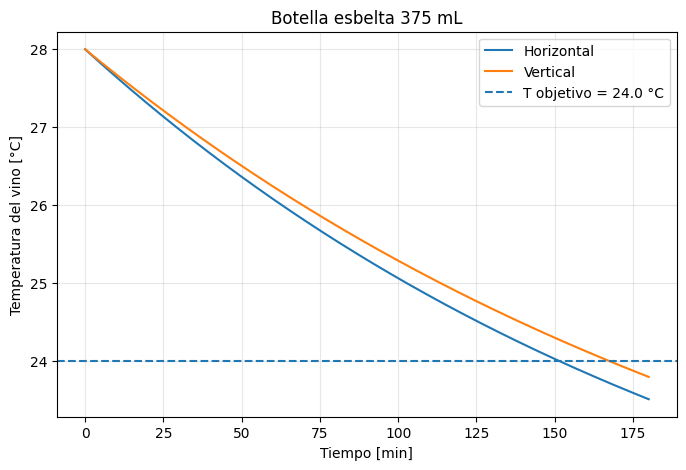

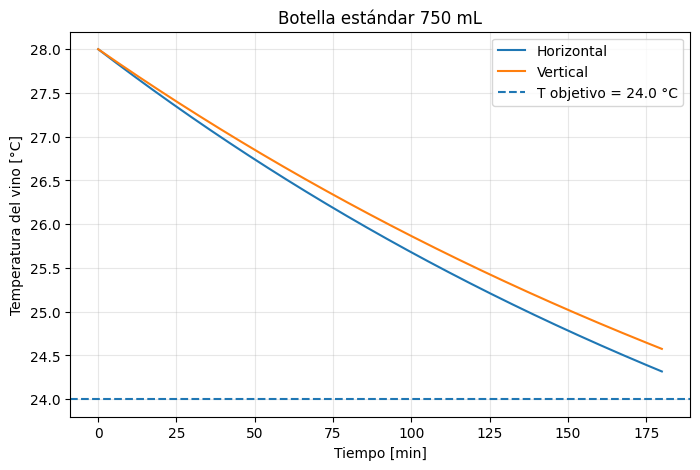

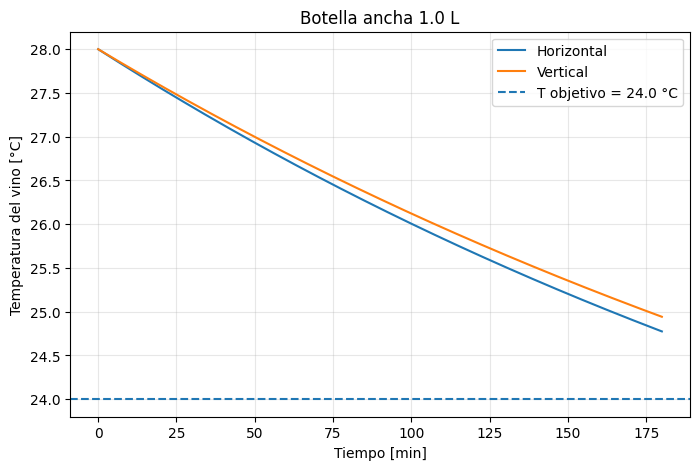

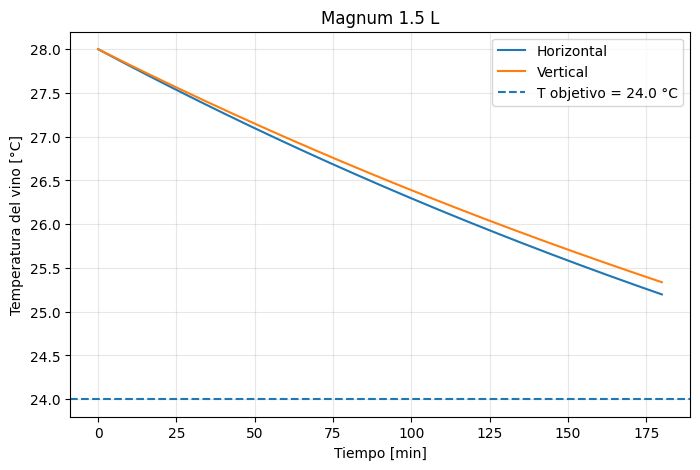

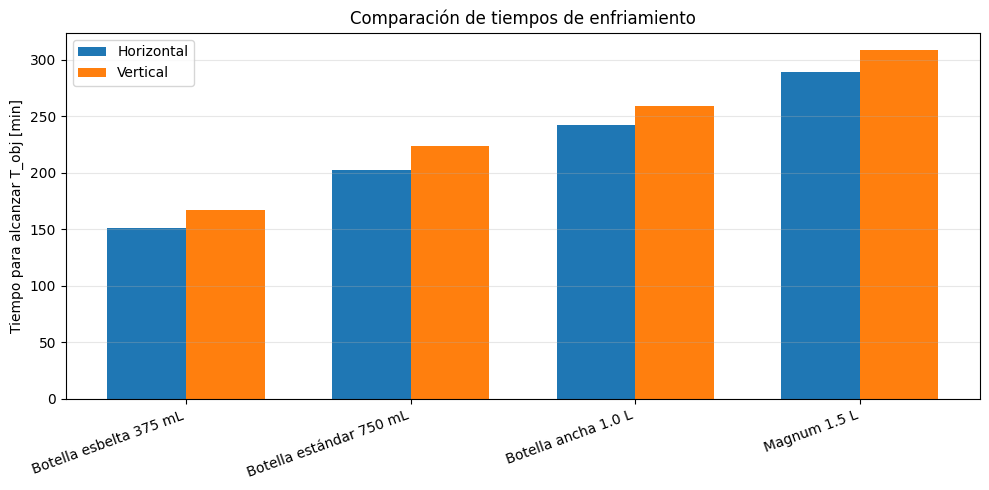


PROPIEDADES DEL AIRE A LA TEMPERATURA DE PELÍCULA
T_film = 24.00 °C
rho    = 1.18831 kg/m^3
mu     = 1.8399738e-05 Pa·s
k      = 0.02617 W/m·K
cp     = 1006.27 J/kg·K
nu     = 1.5483889e-05 m^2/s
alpha  = 2.1887545e-05 m^2/s
Pr     = 0.70743
beta   = 3.3653037e-03 1/K


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# ============================================================
# PARÁMETROS GENERALES DEL PROBLEMA
# ============================================================

g = 9.81                     # m/s^2
T_inf_C = 20.0              # °C, ambiente
T_i_C = 28.0                # °C, vino inicialmente
T_obj_C = 24.0              # °C, temperatura objetivo para comparar rapidez de enfriamiento

# Propiedades aproximadas del vino
rho_wine = 990.0            # kg/m^3
cp_wine = 3900.0            # J/(kg·K)

# Diferentes "botellas" idealizadas como cilindros
# nombre, D [m], L [m]
bottles = [
    ("Botella esbelta 375 mL", 0.060, 0.220),
    ("Botella estándar 750 mL", 0.076, 0.300),
    ("Botella ancha 1.0 L",     0.090, 0.300),
    ("Magnum 1.5 L",            0.105, 0.350),
]

# ============================================================
# FUNCIONES GEOMÉTRICAS
# ============================================================

def cylinder_area(D, L):
    return np.pi * D * L + 2.0 * (np.pi * D**2 / 4.0)

def cylinder_volume(D, L):
    return np.pi * D**2 * L / 4.0

# ============================================================
# PROPIEDADES DEL AIRE CON COOLPROP
# ============================================================

def air_properties(Tfilm_C, P=101325.0):
    Tfilm_K = Tfilm_C + 273.15
    rho = PropsSI("D", "T", Tfilm_K, "P", P, "Air")         # kg/m^3
    mu  = PropsSI("V", "T", Tfilm_K, "P", P, "Air")         # Pa·s
    k   = PropsSI("L", "T", Tfilm_K, "P", P, "Air")         # W/m·K
    cp  = PropsSI("C", "T", Tfilm_K, "P", P, "Air")         # J/kg·K
    nu = mu / rho
    alpha = k / (rho * cp)
    Pr = nu / alpha
    beta = 1.0 / Tfilm_K   # 1/K, gas ideal
    return {
        "rho": rho,
        "mu": mu,
        "k": k,
        "cp": cp,
        "nu": nu,
        "alpha": alpha,
        "Pr": Pr,
        "beta": beta,
        "Tfilm_K": Tfilm_K
    }

# ============================================================
# CORRELACIONES DE NUSSELT
# ============================================================

def Nu_horizontal_cylinder(Ra, Pr):
    # Churchill & Chu para cilindro horizontal
    return (0.60 + (0.387 * Ra**(1.0/6.0)) /
            (1.0 + (0.559/Pr)**(9.0/16.0))**(8.0/27.0))**2

def Nu_vertical_plate(Ra, Pr):
    # Churchill & Chu para placa vertical
    return (0.825 + (0.387 * Ra**(1.0/6.0)) /
            (1.0 + (0.492/Pr)**(9.0/16.0))**(8.0/27.0))**2

# ============================================================
# h PARA CADA ORIENTACIÓN
# ============================================================

def h_horizontal(Ts_C, Tinf_C, D):
    Tfilm_C = 0.5 * (Ts_C + Tinf_C)
    props = air_properties(Tfilm_C)
    deltaT = abs(Ts_C - Tinf_C)
    Ra_D = g * props["beta"] * deltaT * D**3 / (props["nu"] * props["alpha"])
    Nu = Nu_horizontal_cylinder(Ra_D, props["Pr"])
    h = Nu * props["k"] / D
    return h, Nu, Ra_D, props

def h_vertical(Ts_C, Tinf_C, L):
    Tfilm_C = 0.5 * (Ts_C + Tinf_C)
    props = air_properties(Tfilm_C)
    deltaT = abs(Ts_C - Tinf_C)
    Ra_L = g * props["beta"] * deltaT * L**3 / (props["nu"] * props["alpha"])
    Nu = Nu_vertical_plate(Ra_L, props["Pr"])
    h = Nu * props["k"] / L
    return h, Nu, Ra_L, props

# ============================================================
# MODELO DE CAPACIDAD CONCENTRADA
# ============================================================

def cooling_constant(h, A, m, cp):
    return h * A / (m * cp)

def temperature_vs_time(t, Ti_C, Tinf_C, b):
    return Tinf_C + (Ti_C - Tinf_C) * np.exp(-b * t)

def time_to_target(Ti_C, Tinf_C, Tobj_C, b):
    # Valida que Tobj esté entre Ti y Tinf para enfriamiento
    if not (Tinf_C < Tobj_C < Ti_C):
        return np.nan
    return np.log((Ti_C - Tinf_C) / (Tobj_C - Tinf_C)) / b

# ============================================================
# CÁLCULOS PARA CADA BOTELLA
# ============================================================

rows = []

for name, D, L in bottles:
    A = cylinder_area(D, L)
    V = cylinder_volume(D, L)
    m = rho_wine * V

    # Para fines del cálculo de h, se toma Ts ~ temperatura inicial del vino
    h_h, Nu_h, Ra_h, props_h = h_horizontal(T_i_C, T_inf_C, D)
    h_v, Nu_v, Ra_v, props_v = h_vertical(T_i_C, T_inf_C, L)

    b_h = cooling_constant(h_h, A, m, cp_wine)
    b_v = cooling_constant(h_v, A, m, cp_wine)

    t_h = time_to_target(T_i_C, T_inf_C, T_obj_C, b_h)
    t_v = time_to_target(T_i_C, T_inf_C, T_obj_C, b_v)

    rows.append({
        "Botella": name,
        "D [m]": D,
        "L [m]": L,
        "Volumen [L]": V * 1000.0,
        "Area [m²]": A,
        "Masa vino [kg]": m,
        "h horizontal [W/m²K]": h_h,
        "Nu horizontal": Nu_h,
        "Ra_D": Ra_h,
        "b horizontal [1/s]": b_h,
        "t_obj horizontal [min]": t_h / 60.0,
        "h vertical [W/m²K]": h_v,
        "Nu vertical": Nu_v,
        "Ra_L": Ra_v,
        "b vertical [1/s]": b_v,
        "t_obj vertical [min]": t_v / 60.0,
        "Más rápido": "Horizontal" if t_h < t_v else "Vertical"
    })

df = pd.DataFrame(rows)

# Mostrar tabla resumen
pd.set_option("display.precision", 4)
print("="*90)
print("RESUMEN DE RESULTADOS")
print("="*90)
display(df)

# ============================================================
# COMENTARIO AUTOMÁTICO
# ============================================================

print("\nCONCLUSIÓN AUTOMÁTICA:")
for _, r in df.iterrows():
    print(f"- {r['Botella']}: se enfría más rápido en orientación {r['Más rápido']}.")

# ============================================================
# CURVAS DE ENFRIAMIENTO
# ============================================================

t_end = 3.0 * 3600.0   # 3 horas
t = np.linspace(0.0, t_end, 500)

for name, D, L in bottles:
    A = cylinder_area(D, L)
    V = cylinder_volume(D, L)
    m = rho_wine * V

    h_h, _, _, _ = h_horizontal(T_i_C, T_inf_C, D)
    h_v, _, _, _ = h_vertical(T_i_C, T_inf_C, L)

    b_h = cooling_constant(h_h, A, m, cp_wine)
    b_v = cooling_constant(h_v, A, m, cp_wine)

    T_h = temperature_vs_time(t, T_i_C, T_inf_C, b_h)
    T_v = temperature_vs_time(t, T_i_C, T_inf_C, b_v)

    plt.figure(figsize=(8,5))
    plt.plot(t/60.0, T_h, label="Horizontal")
    plt.plot(t/60.0, T_v, label="Vertical")
    plt.axhline(T_obj_C, linestyle="--", label=f"T objetivo = {T_obj_C} °C")
    plt.xlabel("Tiempo [min]")
    plt.ylabel("Temperatura del vino [°C]")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# ============================================================
# GRÁFICA COMPARATIVA DE TIEMPOS
# ============================================================

x = np.arange(len(df))
w = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - w/2, df["t_obj horizontal [min]"], width=w, label="Horizontal")
plt.bar(x + w/2, df["t_obj vertical [min]"], width=w, label="Vertical")
plt.xticks(x, df["Botella"], rotation=20, ha="right")
plt.ylabel("Tiempo para alcanzar T_obj [min]")
plt.title("Comparación de tiempos de enfriamiento")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PROPIEDADES DEL AIRE USADAS EN LA TEMPERATURA DE PELÍCULA
# ============================================================

Tfilm_C = 0.5 * (T_i_C + T_inf_C)
props = air_properties(Tfilm_C)

print("\nPROPIEDADES DEL AIRE A LA TEMPERATURA DE PELÍCULA")
print(f"T_film = {Tfilm_C:.2f} °C")
print(f"rho    = {props['rho']:.5f} kg/m^3")
print(f"mu     = {props['mu']:.7e} Pa·s")
print(f"k      = {props['k']:.5f} W/m·K")
print(f"cp     = {props['cp']:.2f} J/kg·K")
print(f"nu     = {props['nu']:.7e} m^2/s")
print(f"alpha  = {props['alpha']:.7e} m^2/s")
print(f"Pr     = {props['Pr']:.5f}")
print(f"beta   = {props['beta']:.7e} 1/K")

